In [1]:
# Cell 1: Toy PRINCE components
# 4-bit state, 8-bit key.  The structure mirrors PRINCE at toy scale:
# k0 || k1, a derived k0', a 4-bit S-box, a linear M-box, and alpha reflection.

MASK4 = 0xF
MASK8 = 0xFF
ALPHA = 0x8

# PRINCE's 4-bit S-box, reused directly because the toy state is one nibble.
SBOX = [0xB, 0xF, 0x3, 0x2, 0xA, 0xC, 0x9, 0x1,
        0x6, 0x7, 0x8, 0x0, 0xE, 0x5, 0xD, 0x4]
INV_SBOX = [0] * 16
for i, y in enumerate(SBOX):
    INV_SBOX[y] = i

# Tiny round constants. RC0 is zero, like real PRINCE.
ROUND_CONSTANTS = [0x0, 0x7, 0xD]
RC0, RC1, RC2 = ROUND_CONSTANTS


def rotl4(x, amount=1):
    amount %= 4
    x &= MASK4
    return ((x << amount) | (x >> (4 - amount))) & MASK4


def ror4(x, amount=1):
    amount %= 4
    x &= MASK4
    return ((x >> amount) | (x << (4 - amount))) & MASK4


def toy_key_schedule(key_8bit):
    """Split K into k0 || k1 and derive a 4-bit k0' analog."""
    key_8bit &= MASK8
    k0 = (key_8bit >> 4) & MASK4
    k1 = key_8bit & MASK4
    k0_prime = (ror4(k0, 1) ^ ((k0 >> 3) & 1)) & MASK4
    return k0, k1, k0_prime


def s_layer(x):
    return SBOX[x & MASK4]


def s_layer_inv(x):
    return INV_SBOX[x & MASK4]


def m_layer(x):
    """A 4-bit involutive linear M-box: applying it twice is identity."""
    x &= MASK4
    b0 = (x >> 0) & 1
    b1 = (x >> 1) & 1
    b2 = (x >> 2) & 1
    b3 = (x >> 3) & 1
    y0 = b0 ^ b1
    y1 = b1
    y2 = b2 ^ b3
    y3 = b3
    return y0 | (y1 << 1) | (y2 << 2) | (y3 << 3)


def m_layer_inv(x):
    return m_layer(x)


def xor_round_key_and_constant(x, round_key, rc):
    return (x ^ round_key ^ rc) & MASK4


print("Toy components loaded")
print(f"SBOX[0x0] = 0x{SBOX[0]:X}, inverse check = {all(INV_SBOX[SBOX[x]] == x for x in range(16))}")
print(f"M-box involutive check = {all(m_layer_inv(m_layer(x)) == x for x in range(16))}")


Toy components loaded
SBOX[0x0] = 0xB, inverse check = True
M-box involutive check = True


In [2]:
# Cell 2: Toy PRINCE implementation

def toy_base_core_forward(x, base_key):
    """Forward keyed permutation used inside the toy PRINCE core."""
    x &= MASK4
    base_key &= 0x7

    x = xor_round_key_and_constant(x, base_key, RC1)
    x = s_layer(x)
    x = m_layer(x)

    x = xor_round_key_and_constant(x, rotl4(base_key, 1), RC2)
    x = s_layer(x)
    x = m_layer(x)
    return x & MASK4


def toy_base_core_inverse(x, base_key):
    """Inverse of toy_base_core_forward."""
    x &= MASK4
    base_key &= 0x7

    x = m_layer_inv(x)
    x = s_layer_inv(x)
    x = xor_round_key_and_constant(x, rotl4(base_key, 1), RC2)

    x = m_layer_inv(x)
    x = s_layer_inv(x)
    x = xor_round_key_and_constant(x, base_key, RC1)
    return x & MASK4


def toy_prince_core(x, k1):
    """
    Toy alpha-reflecting core.

    ALPHA flips the high bit of k1.  Low three bits choose the keyed
    permutation; the high bit chooses forward vs inverse. Therefore:
        core(x, k1 xor ALPHA) == inverse_core(x, k1)
    """
    base_key = k1 & 0x7
    reflected = (k1 & ALPHA) != 0
    if reflected:
        return toy_base_core_inverse(x, base_key)
    return toy_base_core_forward(x, base_key)


def toy_prince_encrypt(plaintext_4bit, key_8bit):
    k0, k1, k0_prime = toy_key_schedule(key_8bit)
    state = plaintext_4bit & MASK4
    state ^= k0
    state ^= RC0
    state = toy_prince_core(state, k1)
    state ^= k0_prime
    return state & MASK4


def toy_prince_decrypt(ciphertext_4bit, key_8bit):
    k0, k1, k0_prime = toy_key_schedule(key_8bit)
    state = ciphertext_4bit & MASK4
    state ^= k0_prime
    state = toy_prince_core(state, k1 ^ ALPHA)
    state ^= RC0
    state ^= k0
    return state & MASK4


def toy_prince_encrypt_verbose(plaintext_4bit, key_8bit):
    k0, k1, k0_prime = toy_key_schedule(key_8bit)
    ciphertext = toy_prince_encrypt(plaintext_4bit, key_8bit)
    return {
        "plaintext": plaintext_4bit & MASK4,
        "key": key_8bit & MASK8,
        "k0": k0,
        "k1": k1,
        "k0_prime": k0_prime,
        "ciphertext": ciphertext,
    }


example = toy_prince_encrypt_verbose(0x9, 0x6D)
print("Toy PRINCE loaded")
for name, value in example.items():
    width = 2 if name == "key" else 1
    print(f"{name:10s}: 0x{value:0{width}X}")


Toy PRINCE loaded
plaintext : 0x9
key       : 0x6D
k0        : 0x6
k1        : 0xD
k0_prime  : 0x3
ciphertext: 0x2


In [3]:
# Cell 3: Tests matching the Main.ipynb style at toy scale

def assert_equal(name, actual, expected):
    status = "PASS" if actual == expected else "FAIL"
    print(f"{name:28s}: {status}  actual=0x{actual:X}, expected=0x{expected:X}")
    assert actual == expected, name


print("=" * 62)
print("TEST 1 - All-zero plaintext and key")
print("=" * 62)
pt1, key1 = 0x0, 0x00
ct1 = toy_prince_encrypt(pt1, key1)
rt1 = toy_prince_decrypt(ct1, key1)
assert_equal("zero encrypt/decrypt", rt1, pt1)
print(f"pt=0x{pt1:X}, key=0x{key1:02X}, ct=0x{ct1:X}")

print("\n" + "=" * 62)
print("TEST 2 - Non-zero plaintext and key")
print("=" * 62)
pt2, key2 = 0x9, 0x6D
ct2 = toy_prince_encrypt(pt2, key2)
rt2 = toy_prince_decrypt(ct2, key2)
assert_equal("non-zero encrypt/decrypt", rt2, pt2)
print(f"pt=0x{pt2:X}, key=0x{key2:02X}, ct=0x{ct2:X}")

print("\n" + "=" * 62)
print("TEST 3 - Reversibility")
print("=" * 62)
for key in range(256):
    seen = [toy_prince_encrypt(pt, key) for pt in range(16)]
    assert sorted(seen) == list(range(16)), f"not a permutation for key 0x{key:02X}"
    for pt in range(16):
        assert toy_prince_decrypt(toy_prince_encrypt(pt, key), key) == pt
print("reversibility over all 256 keys and 16 plaintexts: PASS")

print("\n" + "=" * 62)
print("TEST 4 - Alpha reflection")
print("=" * 62)
for k1 in range(16):
    for x in range(16):
        y = toy_prince_core(x, k1)
        recovered = toy_prince_core(y, k1 ^ ALPHA)
        assert recovered == x, f"alpha reflection failed for k1=0x{k1:X}, x=0x{x:X}"
print(f"core(x, k1 xor alpha) reverses core(x, k1) for alpha=0x{ALPHA:X}: PASS")

print("\nAll toy PRINCE tests passed.")


TEST 1 - All-zero plaintext and key
zero encrypt/decrypt        : PASS  actual=0x0, expected=0x0
pt=0x0, key=0x00, ct=0xB

TEST 2 - Non-zero plaintext and key
non-zero encrypt/decrypt    : PASS  actual=0x9, expected=0x9
pt=0x9, key=0x6D, ct=0x2

TEST 3 - Reversibility
reversibility over all 256 keys and 16 plaintexts: PASS

TEST 4 - Alpha reflection
core(x, k1 xor alpha) reverses core(x, k1) for alpha=0x8: PASS

All toy PRINCE tests passed.


In [4]:
# Cell 4: Grover iterations over the 2^8 toy-key superposition
import math
import numpy as np


def matching_keys(known_pairs):
    matches = []
    for key in range(256):
        if all(toy_prince_encrypt(pt, key) == ct for pt, ct in known_pairs):
            matches.append(key)
    return matches


def grover_oracle(amplitudes, marked_keys):
    out = amplitudes.copy()
    out[marked_keys] *= -1
    return out


def grover_diffuser(amplitudes):
    mean = np.mean(amplitudes)
    return (2 * mean) - amplitudes


def run_grover_iterations(known_pairs, threshold=0.90, max_iterations=32):
    """Run Grover iterations and store all 256 key probabilities each time."""
    marked = matching_keys(known_pairs)
    amplitudes = np.ones(256, dtype=float) / math.sqrt(256)

    probability_history = []
    iteration_summaries = []

    for iteration in range(max_iterations + 1):
        probabilities = amplitudes ** 2
        probability_by_key = {key: float(probabilities[key]) for key in range(256)}
        probability_history.append(probability_by_key)

        top_key = int(np.argmax(probabilities))
        top_probability = float(probabilities[top_key])
        marked_probability = float(probabilities[marked].sum()) if marked else 0.0
        iteration_summaries.append({
            "iteration": iteration,
            "top_key": top_key,
            "top_probability": top_probability,
            "marked_probability": marked_probability,
        })

        if iteration > 0 and top_probability >= threshold:
            break
        if iteration == max_iterations:
            break

        amplitudes = grover_diffuser(grover_oracle(amplitudes, marked))

    return marked, amplitudes, probability_history, iteration_summaries


secret_key = 0x6D
grover_threshold = 0.99
max_grover_iterations = 32
plaintexts = [0x9, 0x2, 0xE]
known_pairs = [(pt, toy_prince_encrypt(pt, secret_key)) for pt in plaintexts]
marked, amplitudes, probability_history, iteration_summaries = run_grover_iterations(
    known_pairs,
    threshold=grover_threshold,
    max_iterations=max_grover_iterations,
)
final_probabilities = probability_history[-1]
final_summary = iteration_summaries[-1]

print("Known plaintext/ciphertext pairs:")
for pt, ct in known_pairs:
    print(f"  pt=0x{pt:X} -> ct=0x{ct:X}")

print(f"\nSearch space size       : 2^8 = 256 keys")
print(f"Secret key              : 0x{secret_key:02X}")
print(f"Marked key candidates   : {[f'0x{k:02X}' for k in marked]}")
print(f"Number of marked states : {len(marked)}")

print("\nGrover iteration summary:")
for summary in iteration_summaries:
    print(
        f"  iter={summary['iteration']:2d}, "
        f"top=0x{summary['top_key']:02X}, "
        f"top_prob={summary['top_probability']:.6f}, "
        f"marked_prob={summary['marked_probability']:.6f}"
    )

print(f"\nStopped after iteration : {final_summary['iteration']}")
print(f"Top key at cutoff       : 0x{final_summary['top_key']:02X}")
print(f"Top probability         : {final_summary['top_probability']:.6f}")
print(f"Stored probability rows : {len(probability_history)}")
print(f"Keys per row            : {len(probability_history[0])}")

# Show the most likely keys at the cutoff.
final_array = np.array([final_probabilities[key] for key in range(256)])
top = np.argsort(final_array)[::-1][:8]
print("\nTop probabilities at cutoff:")
for rank, key in enumerate(top, start=1):
    print(f"  {rank}. key=0x{key:02X}, probability={final_probabilities[key]:.6f}")

assert secret_key in marked
assert np.isclose(sum(final_probabilities.values()), 1.0)
assert final_summary["top_probability"] >= grover_threshold
print("\nGrover simulation complete.")


Known plaintext/ciphertext pairs:
  pt=0x9 -> ct=0x2
  pt=0x2 -> ct=0x4
  pt=0xE -> ct=0x3

Search space size       : 2^8 = 256 keys
Secret key              : 0x6D
Marked key candidates   : ['0x6D']
Number of marked states : 1

Grover iteration summary:
  iter= 0, top=0x00, top_prob=0.003906, marked_prob=0.003906
  iter= 1, top=0x6D, top_prob=0.034791, marked_prob=0.034791
  iter= 2, top=0x6D, top_prob=0.094638, marked_prob=0.094638
  iter= 3, top=0x6D, top_prob=0.179721, marked_prob=0.179721
  iter= 4, top=0x6D, top_prob=0.284743, marked_prob=0.284743
  iter= 5, top=0x6D, top_prob=0.403166, marked_prob=0.403166
  iter= 6, top=0x6D, top_prob=0.527618, marked_prob=0.527618
  iter= 7, top=0x6D, top_prob=0.650350, marked_prob=0.650350
  iter= 8, top=0x6D, top_prob=0.763722, marked_prob=0.763722
  iter= 9, top=0x6D, top_prob=0.860676, marked_prob=0.860676
  iter=10, top=0x6D, top_prob=0.935176, marked_prob=0.935176
  iter=11, top=0x6D, top_prob=0.982583, marked_prob=0.982583
  iter=12, top

In [5]:
# Cell 5: Print all stored Grover probabilities by iteration
# Run Cell 4 first so probability_history exists.

print("All stored probabilities by iteration:")
for iteration, probability_by_key in enumerate(probability_history):
    print(f"\nIteration {iteration}:")
    for start_key in range(0, 256, 8):
        row = []
        for key in range(start_key, start_key + 8):
            row.append(f"0x{key:02X}:{probability_by_key[key]:.6f}")
        print("  " + "  ".join(row))


All stored probabilities by iteration:

Iteration 0:
  0x00:0.003906  0x01:0.003906  0x02:0.003906  0x03:0.003906  0x04:0.003906  0x05:0.003906  0x06:0.003906  0x07:0.003906
  0x08:0.003906  0x09:0.003906  0x0A:0.003906  0x0B:0.003906  0x0C:0.003906  0x0D:0.003906  0x0E:0.003906  0x0F:0.003906
  0x10:0.003906  0x11:0.003906  0x12:0.003906  0x13:0.003906  0x14:0.003906  0x15:0.003906  0x16:0.003906  0x17:0.003906
  0x18:0.003906  0x19:0.003906  0x1A:0.003906  0x1B:0.003906  0x1C:0.003906  0x1D:0.003906  0x1E:0.003906  0x1F:0.003906
  0x20:0.003906  0x21:0.003906  0x22:0.003906  0x23:0.003906  0x24:0.003906  0x25:0.003906  0x26:0.003906  0x27:0.003906
  0x28:0.003906  0x29:0.003906  0x2A:0.003906  0x2B:0.003906  0x2C:0.003906  0x2D:0.003906  0x2E:0.003906  0x2F:0.003906
  0x30:0.003906  0x31:0.003906  0x32:0.003906  0x33:0.003906  0x34:0.003906  0x35:0.003906  0x36:0.003906  0x37:0.003906
  0x38:0.003906  0x39:0.003906  0x3A:0.003906  0x3B:0.003906  0x3C:0.003906  0x3D:0.003906  0x3E:0.0

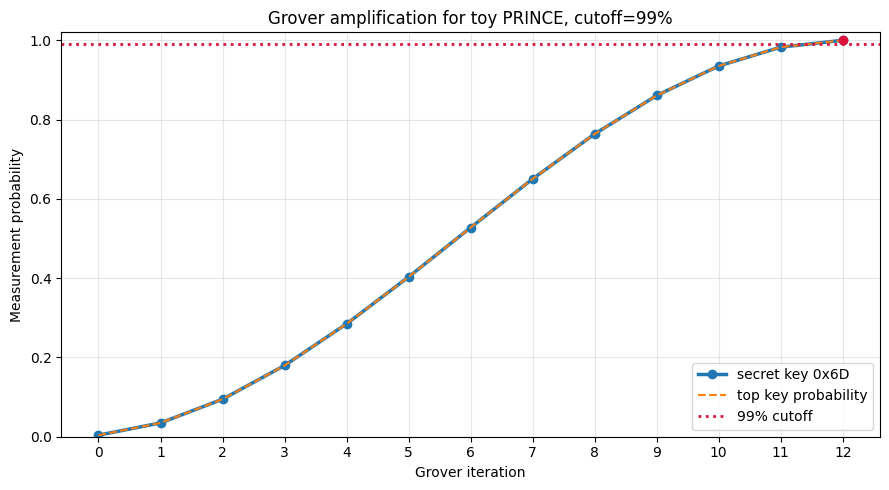

In [7]:
# Cell 6: Visualize the secret key probability amplification
# Run Cell 4 first so probability_history exists.

import matplotlib.pyplot as plt

cutoff = globals().get("grover_threshold", final_summary["top_probability"])
cutoff_percent = cutoff * 100
iterations = list(range(len(probability_history)))
secret_probabilities = [probability_by_key[secret_key] for probability_by_key in probability_history]
top_probabilities = [summary["top_probability"] for summary in iteration_summaries]
final_iteration = final_summary["iteration"]
final_top_key = final_summary["top_key"]
final_top_probability = final_summary["top_probability"]

plt.figure(figsize=(9, 5))
plt.plot(iterations, secret_probabilities, marker="o", linewidth=2.5, label=f"secret key 0x{secret_key:02X}")
plt.plot(iterations, top_probabilities, linestyle="--", linewidth=1.5, label="top key probability")
plt.axhline(cutoff, color="crimson", linestyle=":", linewidth=2, label=f"{cutoff_percent:.0f}% cutoff")
plt.scatter([final_iteration], [final_top_probability], color="crimson", zorder=5)

plt.xticks(iterations)
plt.ylim(0, 1.02)
plt.xlabel("Grover iteration")
plt.ylabel("Measurement probability")
plt.title(f"Grover amplification for toy PRINCE, cutoff={cutoff_percent:.0f}%")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Cell 7: Final Toy PRINCE + one-iteration Grover attack circuit diagrams
# Run Cells 1-4 first so known_pairs, secret_key, and final_summary exist.

from pathlib import Path

import matplotlib.pyplot as plt
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.circuit import Gate
try:
    from IPython.display import Image, display
except Exception:
    Image = None
    display = None


DIAGRAM_DIR = Path("Diagrams")
DIAGRAM_DIR.mkdir(exist_ok=True)


def _append_xor_constant(qc, register, constant, width=4):
    for bit in range(width):
        if (constant >> bit) & 1:
            qc.x(register[bit])


def toy_prince_encryption_block_diagram():
    """Readable block-level diagram of the complete toy PRINCE encryption."""
    state = QuantumRegister(4, "state")
    key = QuantumRegister(8, "key")
    qc = QuantumCircuit(state, key, name="Toy PRINCE encryption")

    k0 = [key[i] for i in range(4, 8)]
    k1 = [key[i] for i in range(0, 4)]

    qc.append(Gate("derive k0'", 4, []), k0)
    qc.barrier()
    qc.append(Gate("pre-whiten: state xor k0 xor RC0", 8, []), list(state) + k0)
    qc.barrier()
    qc.append(Gate("toy core: R1 -> S -> M -> R2 -> S -> M", 8, []), list(state) + k1)
    qc.barrier()
    qc.append(Gate("post-whiten: state xor k0'", 8, []), list(state) + k0)
    return qc


def toy_prince_oracle_gate(pair_index, plaintext_4bit, target_ciphertext_4bit):
    label = (
        f"Oracle pair {pair_index}: full Toy PRINCE E_K "
        f"P={plaintext_4bit:X}, compare C={target_ciphertext_4bit:X}, uncompute"
    )
    return Gate(label, 13, [])


def toy_prince_encryption_gate(label="Toy PRINCE E_K"):
    return Gate(label, 12, [])


def toy_key_diffuser_gate():
    key = QuantumRegister(8, "key")
    diffuser = QuantumCircuit(key, name="Grover diffuser")
    diffuser.h(key)
    diffuser.x(key)
    diffuser.h(key[7])
    diffuser.mcx(key[:7], key[7])
    diffuser.h(key[7])
    diffuser.x(key)
    diffuser.h(key)
    return diffuser.to_gate(label="8-key diffuser")


def append_ciphertext_phase_mark(qc, state, phase, ciphertext_4bit):
    """Flip phase only when the 4-bit state equals ciphertext_4bit."""
    for bit in range(4):
        if ((ciphertext_4bit >> bit) & 1) == 0:
            qc.x(state[bit])
    qc.mcx(state[:], phase[0])
    for bit in range(4):
        if ((ciphertext_4bit >> bit) & 1) == 0:
            qc.x(state[bit])


def build_final_toy_prince_grover_circuit(known_pairs, grover_iterations=None):
    """
    Build the final block-level Grover attack circuit for toy PRINCE key search.

    Registers:
      key[0..7]   : searched 8-bit key, prepared in superposition
      state[0..3] : plaintext/ciphertext work register
      phase       : |-> phase-kickback qubit
      meas_key    : measured key bits at the end
    """
    if grover_iterations is None:
        grover_iterations = globals().get("final_summary", {}).get("iteration", 1)

    key = QuantumRegister(8, "key")
    state = QuantumRegister(4, "state")
    phase = QuantumRegister(1, "phase")
    meas_key = ClassicalRegister(8, "meas_key")
    qc = QuantumCircuit(key, state, phase, meas_key, name="Toy PRINCE Grover attack")

    qc.h(key)
    qc.x(phase[0])
    qc.h(phase[0])
    qc.barrier(label="prepare |K> superposition and |-> phase")

    diffuser = toy_key_diffuser_gate()

    for iteration in range(grover_iterations):
        qc.barrier(label=f"Grover iteration {iteration + 1}")
        for pair_index, (plaintext_4bit, ciphertext_4bit) in enumerate(known_pairs, start=1):
            oracle = toy_prince_oracle_gate(pair_index, plaintext_4bit, ciphertext_4bit)
            qc.append(oracle, list(state) + list(key) + list(phase))
        qc.append(diffuser, key[:])

    qc.barrier(label="measure recovered key")
    qc.measure(key, meas_key)
    return qc


toy_prince_diagram = toy_prince_encryption_block_diagram()
diagram_grover_iterations = 1
grover_full_circuit = build_final_toy_prince_grover_circuit(
    known_pairs,
    grover_iterations=diagram_grover_iterations,
)

def save_circuit_diagram(qc, png_path, fold=80):
    """Save a circuit diagram, falling back when Qiskit's mpl drawer is unavailable."""
    try:
        fig = qc.draw("mpl", fold=fold, idle_wires=False, style="iqp")
        fig.savefig(png_path, dpi=220, bbox_inches="tight")
        plt.close(fig)
        return png_path, None
    except Exception as exc:
        text_diagram = str(qc.draw("text", fold=fold, idle_wires=False))
        txt_path = png_path.with_suffix(".txt")
        txt_path.write_text(text_diagram, encoding="utf-8")

        lines = text_diagram.splitlines()
        width = max(len(line) for line in lines) if lines else 80
        height = max(len(lines), 1)
        fig_width = min(max(width * 0.085, 10), 80)
        fig_height = min(max(height * 0.22, 4), 120)
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        ax.axis("off")
        ax.text(0, 1, text_diagram, family="monospace", fontsize=8, va="top", ha="left")
        fig.savefig(png_path, dpi=220, bbox_inches="tight")
        plt.close(fig)
        return png_path, txt_path


def save_grover_attack_overview(known_pairs, grover_iterations, png_path):
    """Save a compact presentation-level diagram of the full attack flow."""
    fig, ax = plt.subplots(figsize=(15, 4.8))
    ax.axis("off")

    boxes = [
        (0.03, 0.56, 0.16, 0.27, "Prepare", "key[0..7] in uniform superposition\nphase qubit in |->"),
        (0.24, 0.56, 0.28, 0.27, "Toy PRINCE oracle", "For each known pair:\nload plaintext -> E_K -> compare ciphertext\nphase flip marked key -> uncompute"),
        (0.58, 0.56, 0.17, 0.27, "Diffuser", "Invert key amplitudes\nabout their mean"),
        (0.81, 0.56, 0.16, 0.27, "Measure", "read meas_key\nrecover candidate key"),
    ]

    for x, y, w, h, title, body in boxes:
        rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=1.8, edgecolor="black")
        ax.add_patch(rect)
        ax.text(x + w / 2, y + h - 0.055, title, ha="center", va="top", fontsize=13, fontweight="bold")
        ax.text(x + w / 2, y + h / 2 - 0.035, body, ha="center", va="center", fontsize=10)

    arrow_y = 0.695
    for start, end in [(0.19, 0.24), (0.52, 0.58), (0.75, 0.81)]:
        ax.annotate("", xy=(end, arrow_y), xytext=(start, arrow_y), arrowprops={"arrowstyle": "->", "lw": 1.8})

    ax.annotate(
        f"repeat oracle + diffuser {grover_iterations} times",
        xy=(0.67, 0.56),
        xytext=(0.39, 0.38),
        arrowprops={"arrowstyle": "->", "lw": 1.5, "connectionstyle": "arc3,rad=-0.35"},
        fontsize=11,
        ha="center",
    )

    pair_text = "Known pairs: " + ", ".join(f"P=0x{pt:X}->C=0x{ct:X}" for pt, ct in known_pairs)
    ax.text(0.5, 0.21, pair_text, ha="center", va="center", fontsize=11)
    ax.text(0.5, 0.11, "Final Toy PRINCE Grover key-search circuit", ha="center", va="center", fontsize=15, fontweight="bold")

    fig.savefig(png_path, dpi=220, bbox_inches="tight")
    plt.close(fig)
    return png_path


toy_prince_path = DIAGRAM_DIR / "toy_prince_full_circuit.png"
grover_path = DIAGRAM_DIR / "toy_prince_grover_attack_full_circuit.png"
grover_overview_path = DIAGRAM_DIR / "toy_prince_grover_attack_overview.png"

toy_png, toy_txt = save_circuit_diagram(toy_prince_diagram, toy_prince_path, fold=-1)
grover_png, grover_txt = save_circuit_diagram(grover_full_circuit, grover_path, fold=-1)
grover_iterations_drawn = diagram_grover_iterations
overview_png = save_grover_attack_overview(known_pairs, grover_iterations_drawn, grover_overview_path)

print("Final circuit diagrams saved:")
print(f"  Toy PRINCE encryption : {toy_png}")
print(f"  Grover attack circuit : {grover_png}")
print(f"  Grover overview       : {overview_png}")
if toy_txt or grover_txt:
    print("Qiskit mpl drawer was unavailable, so text diagrams were also saved:")
    if toy_txt:
        print(f"  {toy_txt}")
    if grover_txt:
        print(f"  {grover_txt}")
print(f"Grover iterations drawn : {grover_iterations_drawn}")
print(f"Known pairs used        : {[(hex(pt), hex(ct)) for pt, ct in known_pairs]}")

if display is not None and Image is not None:
    display(Image(filename=str(overview_png)))
    display(Image(filename=str(toy_png)))
    display(Image(filename=str(grover_png)))
